In [1]:
import symlib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from helpers.SimulationAnalysis import SimulationAnalysis, readHlist, a2z
import pandas as pd
from matplotlib import colormaps
import matplotlib.colors as mcolors
import scipy
import sklearn
from scipy import stats

ModuleNotFoundError: No module named 'helpers.SimulationAnalysis'

1 SymphonyLMC
2 SymphonyMilkyWay
3 SymphonyGroup
4 SymphonyLCluster
5 SymphonyCluster


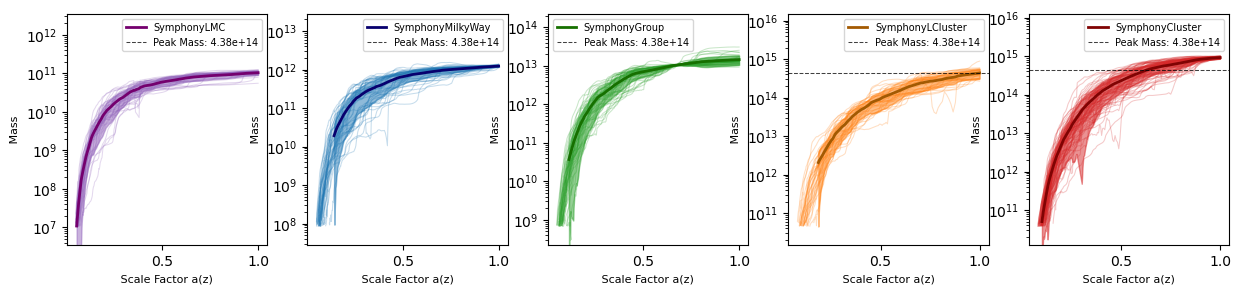

In [98]:
base_dir = "C://Users/steph/MWest_data"
#suite_list = ["SymphonyLMC", "SymphonyCluster"]
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]

fig, ax = plt.subplots(ncols = 5, nrows = 1, figsize = (15, 3))
colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]
avg_colors = [(102/225, 0/255, 110/255), (7/255, 0/255, 110/255), (22/255, 112/255, 0/255), (163/255, 90/255, 2/255), (128/255, 3/255, 3/255)]

for index, suite in enumerate(suite_list):
    print(index + 1, suite)
    
    n_hosts = symlib.n_hosts(suite)
    #n_hosts = 2

    masses_suite = np.zeros(n_hosts, dtype = 'object')

    for i_host in range(n_hosts):
        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)
        h, hist = symlib.read_subhalos(sim_dir)
        scale_factors = symlib.scale_factors(sim_dir)

        params = symlib.simulation_parameters(sim_dir)
        particle_mass = params["mp"]
        
        host_mass = np.array(h["mvir"][0])
        num_particles = host_mass / particle_mass
                
        scale_factors_masked = np.where(host_mass < 300 * particle_mass, np.nan, scale_factors)
        mass_masked = np.where(host_mass < 300 * particle_mass, np.nan, host_mass)
        ax[index].plot(scale_factors_masked, mass_masked, color = colors[index], lw = 0.75, alpha = 0.25)
        masses_suite[i_host] = mass_masked

    vstacked_masses = np.vstack(masses_suite)
    avg_masses = np.nansum(vstacked_masses, axis = 0) / n_hosts
    avg_masses_mask = np.where(avg_masses < 300 * particle_mass, np.nan, avg_masses)
    std_dev = np.nanstd(vstacked_masses, axis = 0)
    
    positive_mask = (avg_masses_mask - std_dev > 0)

    ax[index].plot(scale_factors[positive_mask], avg_masses_mask[positive_mask], color = avg_colors[index], lw = 2, label = f"{suite}")
    ax[index].fill_between(scale_factors[positive_mask], avg_masses_mask[positive_mask] + std_dev[positive_mask],
                    avg_masses_mask[positive_mask] -std_dev[positive_mask], color = colors[index], alpha = 0.5)

    ax[index].axhline(y = avg_masses_suite[-1], color = "black", linestyle = '--', lw = 0.75, alpha = 0.75, label = f"Peak Mass: {(avg_masses_suite[-1]):.2e}")
    #ax.axvline(x = scale_factors[0], color = "black", linestyle = '--', lw = 0.8, alpha = 0.9, label = f"First Scale Factor: {scale_factors[0]:.2f}")
    ax[index].set_yscale("log")
    ax[index].set_xlabel(r" Scale Factor a(z) ", fontsize = 8)
    ax[index].set_ylabel(r" Mass ", fontsize = 8)
    ax[index].set_ylim(1e2 * particle_mass, 1e8 * particle_mass)
    #ax.set_ylim(5e6, 1e16)
    ax[index].legend(loc = 'best', fontsize = 7)
    #ax[index].set_title(f"{suite} > 300x Particle Mass", loc = "center", fontsize = 8)

#fig.suptitle("Total and Average Mass Accretion Histories Of All Suites", fontsize = 13, y = 0.95)
plt.show()